# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 38     |  |
| :-------------|:-------------|
| J.P. Kooloos| 6532241 |
| T.D.H. van Zeeland| 6479510 |
| P. van Beers| 6542026 |

| Planning Groep: 38     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 13:00-13:30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:00-15:00 |
| Pauze 1| 12:30-13:00 |
| Pauze 2| NVT |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](image0.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor| Bezetting wc aangeven, als het licht in de wc aanstaat, dan geef de sensor aan dat de wc bezet is | - Instrument moet alleen lichtintensiteit binnen de wc meten - Instrument moet onderscheid kunnen maken tussen de situaties: I_m >= I_c en I_m < I_c ,met I_wc,deur,open>I_c>I_wc,aan waarbij I_m de gemeten lichtintensiteit is, I_c een constante lichtintensiteit is, I_wc,deur,open de lichtintensiteit van de wc met het licht uit en de deur open, en I_wc,aan de lichtintensiteit van de wc als het licht aan is. I_wc,deur,open = 425 lux I_wc,aan = 826 en dus: 826>I_c>826
|Temperatuur sensor | De temperatuursensor geeft aan hoe warm de thee(mok) is en gaat af als de thee te koud wordt om er nog van te genieten | -Instrument moet alleen de temperatuur van de thee T_thee meten-Instrument moet onderscheid kunnen maken tussen meetwaarde T_m >= T_hee h en meetwaarde T_m <= T_c, waarbij T_h de temperatuur is waarbij de thee je mond zou verbranden, en T_c kamertemperatuur is. -Temperatuursensor moet de temperatuur van de thee kunnen meten zonder dat er kortsluiting veroorzaakt wordt. T_c = 60 celsius, T_h = 80 celsius|
| Magneetsensor | De magneetsensor meet de omwenteling van een wiel door te detecteren wanneer er een magneet langsgaat en kan zo de snelheid bepalen | - De magneetsensor moet het verschil tussen een magneet (met een veldsterkte van 1.35 Tesla) op 1 centimeter afstand en diezelfde magneet op 50 cm afstand.- De magneetsensor moet een meetbaar signaal geven als een magneet (met een veldsterkte van 1.35 Tesla) met een snelheid tussen de 0 en 40 km/h op 1 centimeter afstand er langs gaat. |


Groep 38 heeft gekozen voor sensor licht. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Hier is een schematische tekening van de opstelling te zien. De laptop, waarop arduino draait, is gepositioneerd op de wc, samen met het arduinoboardje met de lichtsensor en de telefoon met de Light Meter LM-3000 app. Deze telefoon is eerst nog omwikkeld met een wit stukje A4 papier die dient als diffuser. Boven de opstelling wordt een telefoon gebruikt als zaklamp om de verlichtingssterkte te variëren. De Verlichtingssterkte is gevariërd door de telefoon op verschillende hoogtes te houden. En daarnaast is er ook een schematische tekening gemaakt van de schakeling.
 ![Alt](Opstelling_schema.jpg "schets student")
 ![Alt](DEF-10.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
De variabele die we gaan veranderen is de Verlichtingssterkte[Lx]
2. Over welk bereik ga je deze variabelen veranderen?
We gaan meten tussen de 0 en 900 lux
3. Wat ga je allemaal meten?
We meten de Verlichtingssterkte meten met de Light Meter LM-3000 app en deze correleren met de verkegen data uit de arduino
4. Hoeveel metingen ga je doen?
10 metingen
8x met de telefoon met het licht uit
1x met alleen het licht uit
1x met het licht van de wc aan
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Wij denken dat we met de gemaakte keuzes een beeld kunnen krijgen of de sensor geschikt is.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Hier is een foto van de daadwerkelijke opstelling te zien. De laptop, waarop arduino draait, is gepositioneerd op de wc, samen met het arduinoboardje met de lichtsensor en de telefoon met de Light Meter LM-3000 app. Deze telefoon is eerst nog omwikkeld met een wit stukje A4 papier die dient als diffuser. Boven de opstelling wordt een telefoon gebruikt als zaklamp om de verlichtingssterkte te variëren. De Verlichtingssterkte is gevariërd door de telefoon op verschillende hoogtes te houden.
 ![Alt](Foto_opstelling.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Lux=np.array([826,0.7,425,22,41,100,200,300,492,620])
sensor=np.array([876,21,791,288,410,587,699,781,862,865])
error_sensor =np.array([1,1,2,1,1,1,1,1,1,1])
error_Lux = Lux*(20/826)




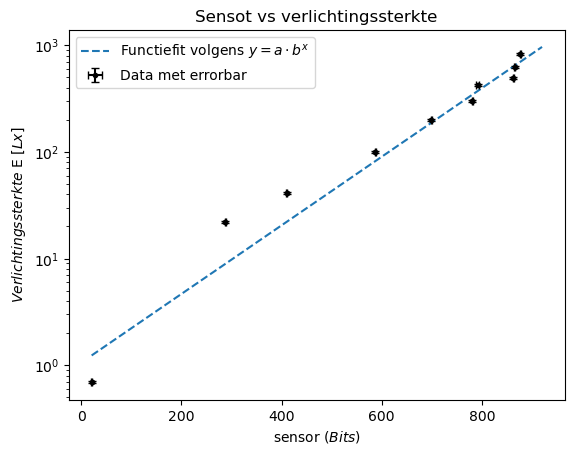

In [2]:
# Plot hier de meting en fit een lijn door de metingen.

def func(x,a,b):
    return a*b**x

val,cov = curve_fit(func,sensor,Lux)

xtest = np.linspace(min(sensor),max(sensor)*1.05,1000)

plt.figure()
plt.plot(sensor,Lux,'k.')
plt.plot(xtest,func(xtest,*val),'--', label="Functiefit volgens $y = a \cdot b^{x} $")
plt.title("Sensot vs verlichtingssterkte")
plt.errorbar(sensor,Lux,xerr=error_sensor,yerr = error_Lux,fmt = 'k.',capsize = 3, label="Data met errorbar")
plt.semilogy()
plt.xlabel("sensor $(Bits)$")
plt.ylabel("$Verlichtingssterkte$ E $[Lx]$")
plt.legend()
plt.show()

# Functiefit volgens $y = a \cdot b^{x} $

# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline


## *Opdracht 7*: Iteratie nodig?

We zien dat bij een verlichtingsterkte van 425 lux de sensor een waarde van 791 geeft. Bij een verlichtingsterkte van 826 lux geeft de sensor een waarde van 876. Tussen deze twee outputs van de sensor zit genoeg verschil om een drempel waarde te kiezen die ons toe kan staan om een circuit te maken waarbij een lampje aangaat als de het licht van de wc aandstaat. Er is dus geen verdere iteratie nodig. 

## *Opdracht 8*: Conclusie, leerdoel

De sensor is sentistief genoeg om het verschil te kunnen waarnemen tussen wanneer een deur open is en wanneer het licht in de wc daadwerkelijk aanstaat (zie iteratie voor de daadwerkelijke waardes). We kunnen namelijk een drempelwaarde van 830 kiezen voor de sensor die aangeeft wanneer de lamp aan en uit moet. We kunnen deze sensor dus gebruiken om een apparaat te maken die aangeeft wanneer de wc bezet is op basis van of het licht wel of niet aanstaat.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Hier is een foto van de daadwerkelijke opstelling te zien. De laptop, waarop arduino draait, is gepositioneerd op de wc, samen met het arduinoboardje met de lichtsensor en de telefoon met de Light Meter LM-3000 app. Deze telefoon is eerst nog omwikkeld met een wit stukje A4 papier die dient als diffuser. Boven de opstelling wordt een telefoon gebruikt als zaklamp om de verlichtingssterkte te variëren. De Verlichtingssterkte is gevariërd door de telefoon op verschillende hoogtes te houden.
 ![Alt](Foto_opstelling.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor| Bezetting wc aangeven, als het licht in de wc aanstaat, dan geef de sensor aan dat de wc bezet is | - Instrument moet alleen lichtintensiteit binnen de wc meten - Instrument moet onderscheid kunnen maken tussen de situaties: I_m >= I_c en I_m < I_c ,met I_wc,deur,open>I_c>I_wc,aan waarbij I_m de gemeten lichtintensiteit is, I_c een constante lichtintensiteit is, I_wc,deur,open de lichtintensiteit van de wc met het licht uit en de deur open, en I_wc,aan de lichtintensiteit van de wc als het licht aan is. I_wc,deur,open = 425 lux I_wc,aan = 826 en dus: 826>I_c>826
|Temperatuur sensor | De temperatuursensor geeft aan hoe warm de thee(mok) is en gaat af als de thee te koud wordt om er nog van te genieten | -Instrument moet alleen de temperatuur van de thee T_thee meten-Instrument moet onderscheid kunnen maken tussen meetwaarde T_m >= T_hee h en meetwaarde T_m <= T_c, waarbij T_h de temperatuur is waarbij de thee je mond zou verbranden, en T_c kamertemperatuur is. -Temperatuursensor moet de temperatuur van de thee kunnen meten zonder dat er kortsluiting veroorzaakt wordt. T_c = 60 celsius, T_h = 80 celsius|
| Magneetsensor | De magneetsensor meet de omwenteling van een wiel door te detecteren wanneer er een magneet langsgaat en kan zo de snelheid bepalen | - De magneetsensor moet het verschil tussen een magneet (met een veldsterkte van 1.35 Tesla) op 1 centimeter afstand en diezelfde magneet op 50 cm afstand.- De magneetsensor moet een meetbaar signaal geven als een magneet (met een veldsterkte van 1.35 Tesla) met een snelheid tussen de 0 en 40 km/h op 1 centimeter afstand er langs gaat. |


Groep 38 heeft gekozen voor sensor licht. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

In [3]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Lux=np.array([826,0.7,425,22,41,100,200,300,492,620])
sensor=np.array([876,21,791,288,410,587,699,781,862,865])
error_sensor =np.array([1,1,2,1,1,1,1,1,1,1])
error_Lux = Lux*(20/826)




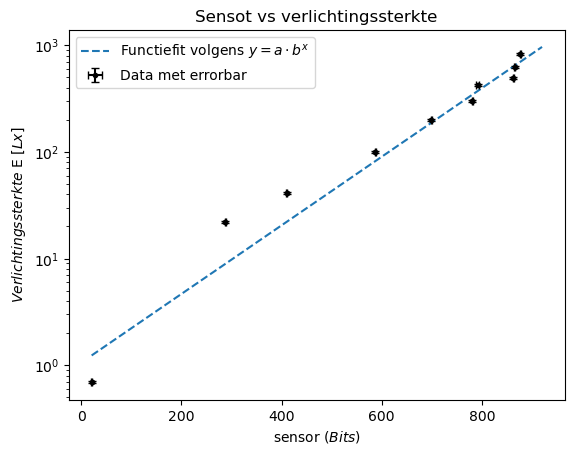

In [4]:
# Plot hier de meting en fit een lijn door de metingen.

def func(x,a,b):
    return a*b**x

val,cov = curve_fit(func,sensor,Lux)

xtest = np.linspace(min(sensor),max(sensor)*1.05,1000)

plt.figure()
plt.plot(sensor,Lux,'k.')
plt.plot(xtest,func(xtest,*val),'--', label="Functiefit volgens $y = a \cdot b^{x} $")
plt.title("Sensot vs verlichtingssterkte")
plt.errorbar(sensor,Lux,xerr=error_sensor,yerr = error_Lux,fmt = 'k.',capsize = 3, label="Data met errorbar")
plt.semilogy()
plt.xlabel("sensor $(Bits)$")
plt.ylabel("$Verlichtingssterkte$ E $[Lx]$")
plt.legend()
plt.show()

# Functiefit volgens $y = a \cdot b^{x} $

# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline


## *Opdracht 8*: Conclusie, leerdoel

De sensor is sentistief genoeg om het verschil te kunnen waarnemen tussen wanneer een deur open is en wanneer het licht in de wc daadwerkelijk aanstaat (zie iteratie voor de daadwerkelijke waardes). We kunnen namelijk een drempelwaarde van 830 kiezen voor de sensor die aangeeft wanneer de lamp aan en uit moet. We kunnen deze sensor dus gebruiken om een apparaat te maken die aangeeft wanneer de wc bezet is op basis van of het licht wel of niet aanstaat.